# Importation et Chargement

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay



from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

!pip install scikeras -q
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier




In [ ]:
!pip install catboost -q
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.inspection import PartialDependenceDisplay

In [ ]:
df=pd.read_csv('CustomerChurn.csv')

# EDA & Nettoyage

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
for column in df.columns:
  num_distinct_values=df[column].nunique()
  print( f"{column:<20} - {num_distinct_values} distinct values")

customerID           - 7043 distinct values
gender               - 2 distinct values
SeniorCitizen        - 2 distinct values
Partner              - 2 distinct values
Dependents           - 2 distinct values
tenure               - 73 distinct values
PhoneService         - 2 distinct values
MultipleLines        - 3 distinct values
InternetService      - 3 distinct values
OnlineSecurity       - 3 distinct values
OnlineBackup         - 3 distinct values
DeviceProtection     - 3 distinct values
TechSupport          - 3 distinct values
StreamingTV          - 3 distinct values
StreamingMovies      - 3 distinct values
Contract             - 3 distinct values
PaperlessBilling     - 2 distinct values
PaymentMethod        - 4 distinct values
MonthlyCharges       - 1585 distinct values
TotalCharges         - 6531 distinct values
Churn                - 2 distinct values


In [ ]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4908,3957-LXOLK,Female,1,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,106.15,3152.5,Yes
657,7838-LAZFO,Male,0,Yes,No,45,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),78.80,3597.5,No
7030,0871-OPBXW,Female,0,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.05,39.25,No
5995,2193-SFWQW,Male,0,Yes,Yes,72,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),111.95,8033.1,No
4071,6537-QLGEX,Female,0,No,No,16,No,No phone service,DSL,Yes,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,38.90,664.4,No


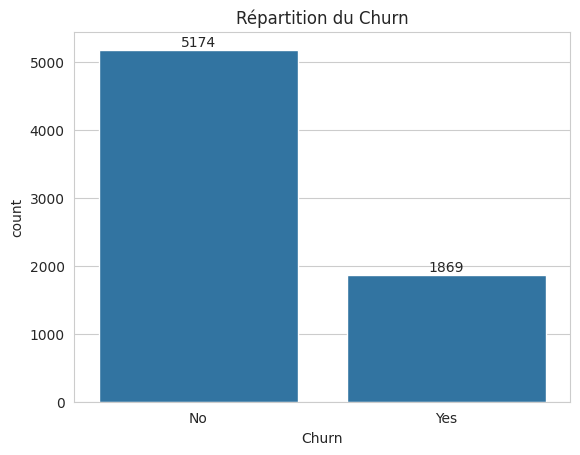

In [ ]:
ax=sns.countplot(data=df, x='Churn')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.title("Répartition du Churn")
plt.show()

In [ ]:
def plot_enhanced_distributions(df, columns, cols_per_row=3, main_title="Analyse des DistributionS  Catégorielles"):

    n_cols = len(columns)
    n_rows = math.ceil(n_cols / cols_per_row)
    sns.set_style("whitegrid")

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 6, n_rows * 5))
    fig.suptitle(main_title, fontsize=22, fontweight='bold', y=1.02)

    palette = sns.color_palette("pastel")

    if n_cols > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for i, col_name in enumerate(columns):
        counts = df[col_name].value_counts()
        total = counts.sum()
        explode = [0.08 if val == counts.max() else 0 for val in counts]

        ax = axes_flat[i]
        wedges, texts, autotexts = ax.pie(
            counts,
            labels=counts.index,
            autopct=lambda p: f'{p:.1f}%\n({int(p*total/100)})',
            startangle=140,
            explode=explode,
            colors=palette,
            shadow=True,
            textprops={'fontsize': 12}
        )

        plt.setp(autotexts, size=10, weight="bold", color="black")
        ax.set_title(f"{col_name}", fontsize=15, fontweight="bold", pad=20)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()



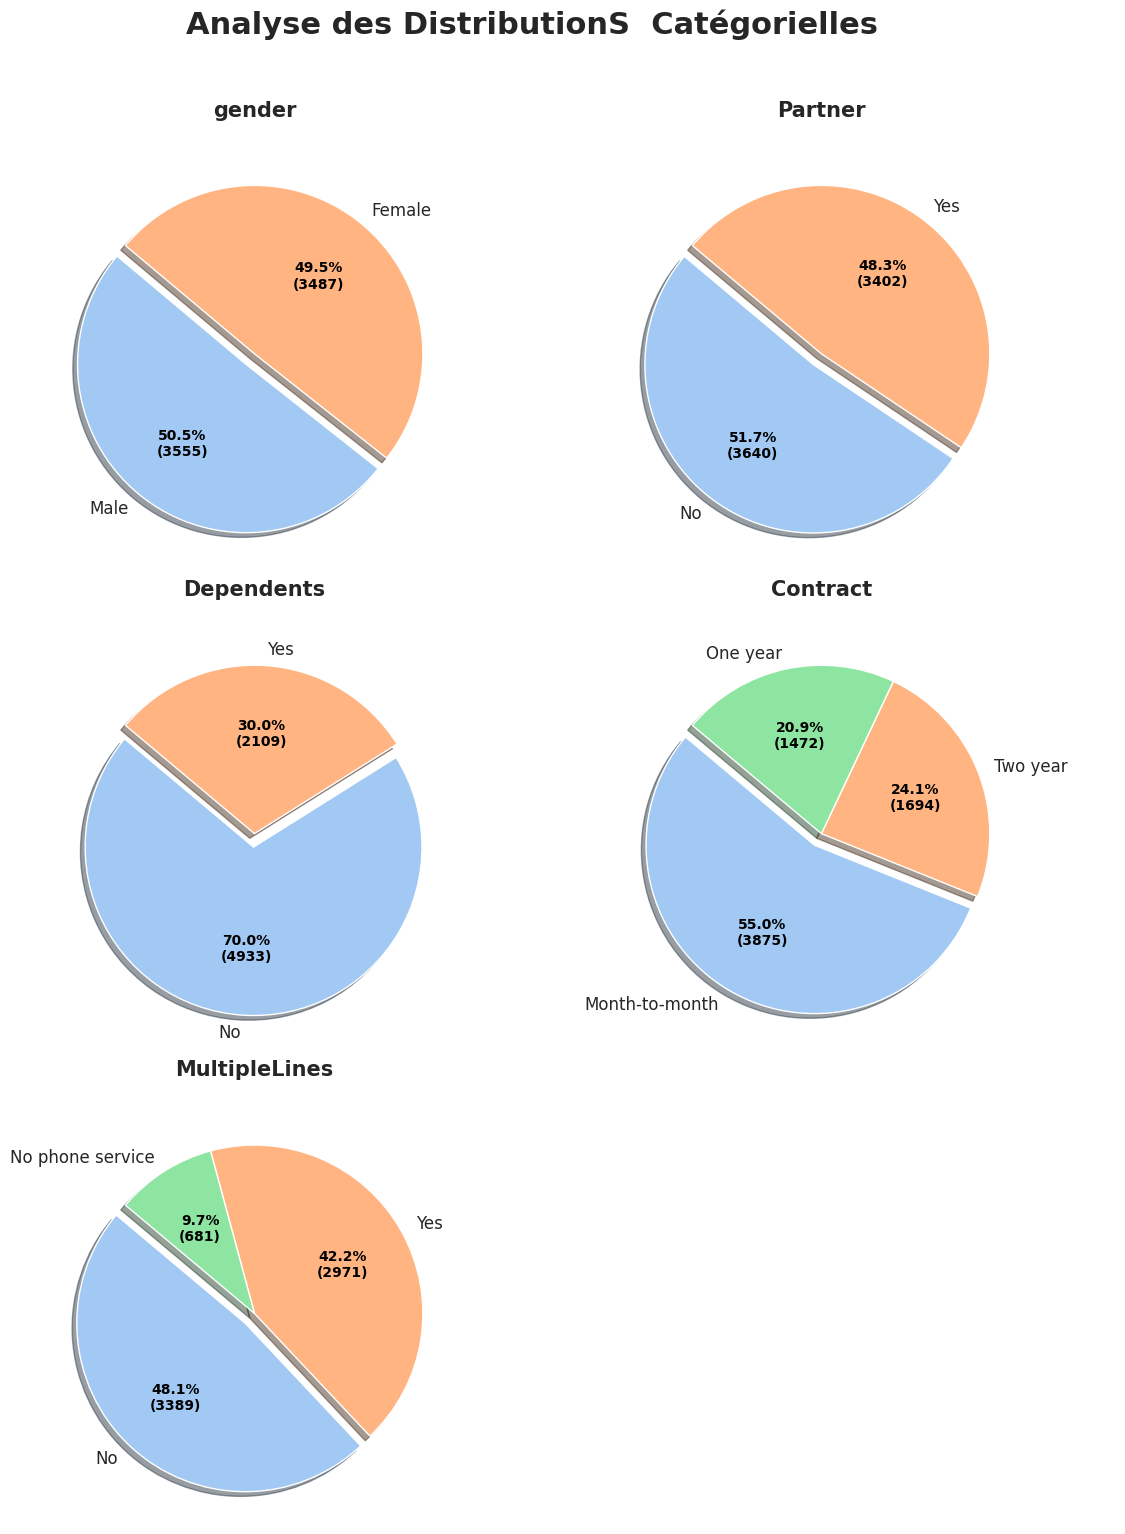

In [ ]:
plot_enhanced_distributions(df, ["gender", "Partner", "Dependents", "Contract","MultipleLines"], cols_per_row=2)

In [ ]:
df = df.drop(columns=['customerID'])

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

df = df.replace({
    'No internet service': 'No',
    'No phone service': 'No'
})

yes_no_columns = [
    'Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity',
    'OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
    'StreamingMovies','PaperlessBilling'
]

df[yes_no_columns] = df[yes_no_columns].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_201/182506873.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yes_no_columns] = df[yes_no_columns].replace({'Yes': 1, 'No': 0})


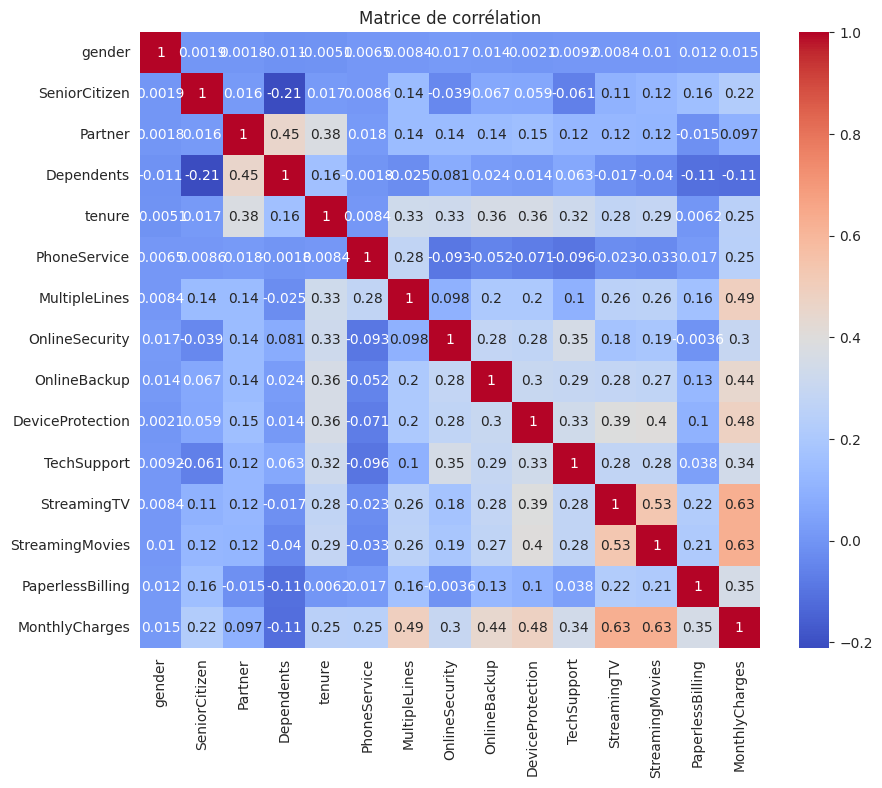

In [ ]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])


/tmp/ipykernel_201/242619952.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn']=='No']['tenure'], label='Fidèle', shade=True)
/tmp/ipykernel_201/242619952.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn']=='Yes']['tenure'], label='Churn', shade=True)


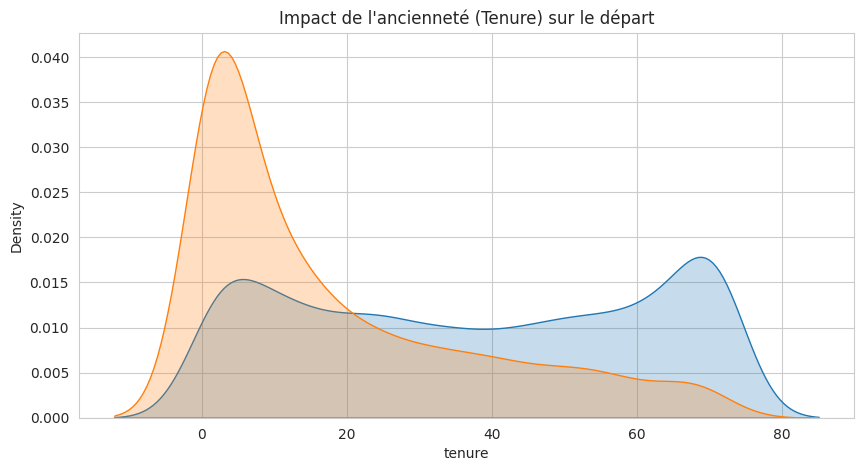

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Churn']=='No']['tenure'], label='Fidèle', shade=True)
sns.kdeplot(df[df['Churn']=='Yes']['tenure'], label='Churn', shade=True)
plt.title("Impact de l'ancienneté (Tenure) sur le départ")
plt.show()

## Feature Engineering

In [ ]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = (df[services] == 'Yes').sum(axis=1)
df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72,100], labels=['0-1y', '1-2y', '2-4y', '4-6y', '6y+'])

In [ ]:
def summary(df):
    summary_df = pd.DataFrame(df.dtypes, columns=['dtypes'])
    summary_df['missing#'] = df.isna().sum()
    summary_df['missing%'] = (df.isna().sum())/len(df)
    summary_df['unique'] = df.nunique().values
    summary_df['count'] = df.count().values
    return summary_df

summary(df).style.background_gradient(cmap='Blues')

,dtypes,missing#,missing%,unique,count
gender,int64,0,0.000000,2,7032
SeniorCitizen,int64,0,0.000000,2,7032
Partner,int64,0,0.000000,2,7032
Dependents,int64,0,0.000000,2,7032
tenure,int64,0,0.000000,72,7032
PhoneService,int64,0,0.000000,2,7032
MultipleLines,int64,0,0.000000,2,7032
InternetService,object,0,0.000000,3,7032
OnlineSecurity,int64,0,0.000000,2,7032
OnlineBackup,int64,0,0.000000,2,7032


# Pipeline Machine Learning & ANN

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']
categorical_features = ['Contract', 'PaymentMethod', 'InternetService', 'Tenure_Group']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


In [ ]:
def create_ann():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_preprocessed.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

ann = create_ann()
history = ann.fit(X_train_preprocessed, y_train, epochs=100, batch_size=32,
                  validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Évaluation & Métriques de Performance

In [ ]:
y_pred_prob = ann.predict(X_test_preprocessed)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_test, y_pred))


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



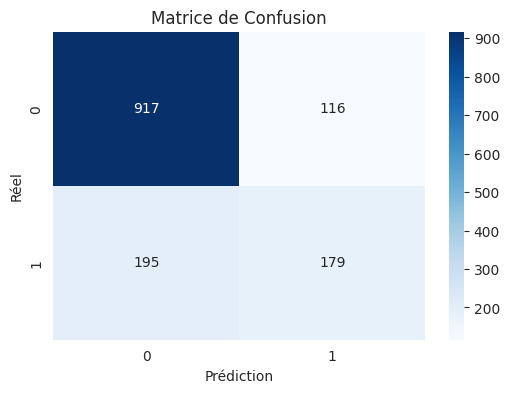

In [ ]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()